![iceberg-logo](https://www.apache.org/logos/res/iceberg/iceberg.png)

In [2]:
from pyiceberg import __version__

__version__

'0.9.1'

## Load NYC Taxi/Limousine Trip Data

For this notebook, we will use the New York City Taxi and Limousine Commision Trip Record Data that's available on the AWS Open Data Registry. This contains data of trips taken by taxis and for-hire vehicles in New York City. We'll save this into an iceberg table called `taxis`.

First, load the Parquet file using PyArrow:

In [1]:
import pyarrow.parquet as pq

tbl_taxis = pq.read_table('/home/iceberg/data/yellow_tripdata_2021-04.parquet')
tbl_taxis

pyarrow.Table
VendorID: int64
tpep_pickup_datetime: timestamp[us]
tpep_dropoff_datetime: timestamp[us]
passenger_count: double
trip_distance: double
RatecodeID: double
store_and_fwd_flag: string
PULocationID: int64
DOLocationID: int64
payment_type: int64
fare_amount: double
extra: double
mta_tax: double
tip_amount: double
tolls_amount: double
improvement_surcharge: double
total_amount: double
congestion_surcharge: double
airport_fee: double
----
VendorID: [[1,1,1,1,2,...,1,1,2,2,2],[2,2,2,1,1,...,2,2,2,2,1],...,[1,1,1,2,2,...,1,6,1,2,2],[2,2,2,1,2,...,2,1,2,2,1]]
tpep_pickup_datetime: [[2021-04-01 00:00:18.000000,2021-04-01 00:42:37.000000,2021-04-01 00:57:56.000000,2021-04-01 00:01:58.000000,2021-04-01 00:24:55.000000,...,2021-04-02 22:16:03.000000,2021-04-02 22:34:19.000000,2021-04-02 22:12:43.000000,2021-04-02 22:41:39.000000,2021-04-02 22:09:28.000000],[2021-04-02 22:20:04.000000,2021-04-02 22:34:37.000000,2021-04-02 22:54:15.000000,2021-04-02 22:06:46.000000,2021-04-02 22:47:17.00

## Creating the table

Next, create the namespace, and the `taxis` table from the schema that's derived from the Arrow schema:

In [3]:
from pyiceberg.catalog import load_catalog
from pyiceberg.exceptions import NamespaceAlreadyExistsError

cat = load_catalog('default')

try:
    cat.create_namespace('default')
except NamespaceAlreadyExistsError:
    pass

In [4]:
from pyiceberg.exceptions import NoSuchTableError

try:
    cat.drop_table('default.taxis_operational')
except NoSuchTableError:
    pass

tbl = cat.create_table(
    'default.taxis_operational',
    schema=tbl_taxis.schema
)

tbl

taxis_operational(
  1: VendorID: optional long,
  2: tpep_pickup_datetime: optional timestamp,
  3: tpep_dropoff_datetime: optional timestamp,
  4: passenger_count: optional double,
  5: trip_distance: optional double,
  6: RatecodeID: optional double,
  7: store_and_fwd_flag: optional string,
  8: PULocationID: optional long,
  9: DOLocationID: optional long,
  10: payment_type: optional long,
  11: fare_amount: optional double,
  12: extra: optional double,
  13: mta_tax: optional double,
  14: tip_amount: optional double,
  15: tolls_amount: optional double,
  16: improvement_surcharge: optional double,
  17: total_amount: optional double,
  18: congestion_surcharge: optional double,
  19: airport_fee: optional double
),
partition by: [],
sort order: [],
snapshot: null

## Write the actual data into the table

This will create a new snapshot on the table:

In [5]:
tbl.overwrite(tbl_taxis)

tbl

/usr/local/lib/python3.10/site-packages/pyiceberg/table/__init__.py:686: UserWarning: Delete operation did not match any records
  warnings.warn("Delete operation did not match any records")


taxis_operational(
  1: VendorID: optional long,
  2: tpep_pickup_datetime: optional timestamp,
  3: tpep_dropoff_datetime: optional timestamp,
  4: passenger_count: optional double,
  5: trip_distance: optional double,
  6: RatecodeID: optional double,
  7: store_and_fwd_flag: optional string,
  8: PULocationID: optional long,
  9: DOLocationID: optional long,
  10: payment_type: optional long,
  11: fare_amount: optional double,
  12: extra: optional double,
  13: mta_tax: optional double,
  14: tip_amount: optional double,
  15: tolls_amount: optional double,
  16: improvement_surcharge: optional double,
  17: total_amount: optional double,
  18: congestion_surcharge: optional double,
  19: airport_fee: optional double
),
partition by: [],
sort order: [],
snapshot: Operation.APPEND: id=3418667222219480614, schema_id=0

## Append more data

Let's append another month of data to the table:

In [9]:
tbl.append(pq.read_table('/home/iceberg/data/yellow_tripdata_2021-05.parquet'))

tbl

taxis(
  1: VendorID: optional long,
  2: tpep_pickup_datetime: optional timestamp,
  3: tpep_dropoff_datetime: optional timestamp,
  4: passenger_count: optional double,
  5: trip_distance: optional double,
  6: RatecodeID: optional double,
  7: store_and_fwd_flag: optional string,
  8: PULocationID: optional long,
  9: DOLocationID: optional long,
  10: payment_type: optional long,
  11: fare_amount: optional double,
  12: extra: optional double,
  13: mta_tax: optional double,
  14: tip_amount: optional double,
  15: tolls_amount: optional double,
  16: improvement_surcharge: optional double,
  17: total_amount: optional double,
  18: congestion_surcharge: optional double,
  19: airport_fee: optional double
),
partition by: [],
sort order: [],
snapshot: Operation.APPEND: id=6771047499783765158, parent_id=4305464451226606759, schema_id=0

## Load data into a PyArrow Dataframe

We'll fetch the table using the REST catalog that comes with the setup.

In [10]:
tbl = cat.load_table('default.taxis')

sc = tbl.scan(row_filter="tpep_pickup_datetime >= '2021-05-01T00:00:00.000000'")

In [11]:
df = sc.to_arrow().to_pandas()

In [12]:
len(df)

2507068

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2507068 entries, 0 to 2507067
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  airport_fee           

In [12]:
df

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,1,2021-05-01 00:37:18,2021-05-01 00:41:07,2.0,0.70,1.0,N,141,263,1,5.0,3.0,0.5,2.20,0.00,0.3,11.00,2.5,0.0
1,1,2021-05-01 00:43:01,2021-05-01 00:49:19,1.0,1.40,1.0,N,263,75,2,6.5,3.0,0.5,0.00,0.00,0.3,10.30,2.5,0.0
2,1,2021-05-01 00:05:54,2021-05-01 00:31:46,1.0,5.70,1.0,N,142,129,2,21.5,3.0,0.5,0.00,0.00,0.3,25.30,2.5,0.0
3,2,2021-05-01 00:08:21,2021-05-01 00:19:20,1.0,3.04,1.0,N,231,97,1,11.5,0.5,0.5,3.06,0.00,0.3,18.36,2.5,0.0
4,2,2021-05-01 00:32:44,2021-05-01 00:48:44,1.0,4.04,1.0,N,148,17,1,15.5,0.5,0.5,5.79,0.00,0.3,25.09,2.5,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2507063,2,2021-05-01 00:00:12,2021-05-01 00:17:40,1.0,4.22,1.0,N,90,262,1,15.5,0.5,0.5,3.86,0.00,0.3,23.16,2.5,0.0
2507064,2,2021-05-01 00:02:06,2021-05-01 00:07:56,2.0,1.34,1.0,N,239,143,1,6.5,0.5,0.5,1.54,0.00,0.3,11.84,2.5,0.0
2507065,2,2021-05-01 00:05:47,2021-05-01 00:14:23,1.0,1.18,1.0,N,87,231,1,7.5,0.5,0.5,2.82,0.00,0.3,14.12,2.5,0.0
2507066,2,2021-05-01 00:00:03,2021-05-01 00:13:04,1.0,3.79,1.0,N,229,151,1,13.5,0.5,0.5,3.46,0.00,0.3,20.76,2.5,0.0


In [14]:
pip install matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 2.6 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 325.0/325.0 kB 2.7 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 2.9 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 2.0 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 5.2 MB/s eta 0:00:00a 0:00:01

[notice] A new release of pip is available: 23.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


array([[<Axes: title={'center': 'fare_amount'}>]], dtype=object)

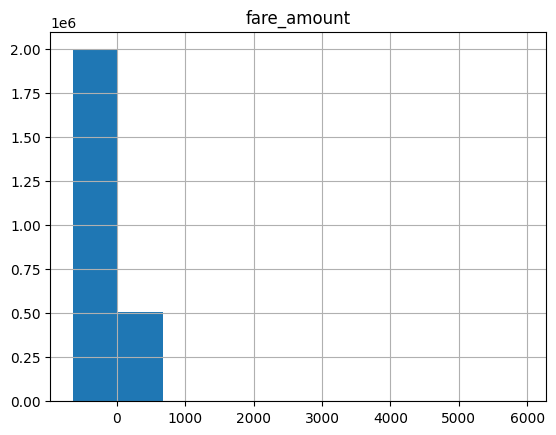

In [15]:
df.hist(column='fare_amount')

In [18]:
pip install scipy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.7/37.7 MB 2.2 MB/s eta 0:00:0000:0100:01

[notice] A new release of pip is available: 23.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [19]:
import numpy as np
from scipy import stats

stats.zscore(df['fare_amount'])

# Remove everything larger than 3 stddev
df = df[(np.abs(stats.zscore(df['fare_amount'])) < 3)]
# Remove everything below zero
df = df[df['fare_amount'] > 0]

array([[<Axes: title={'center': 'fare_amount'}>]], dtype=object)

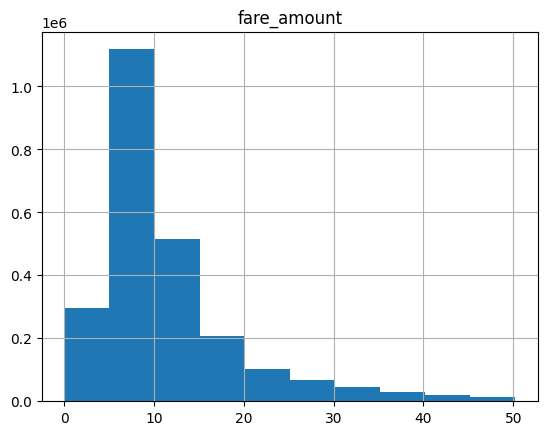

In [20]:
df.hist(column='fare_amount')

# DuckDB

Use DuckDB to Query the PyArrow Dataframe directly.

In [22]:
pip install ipython-sql

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 5.5 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.1/46.1 kB 1.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 612.9/612.9 kB 8.5 MB/s eta 0:00:00a 0:00:01

[notice] A new release of pip is available: 23.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [24]:
pip install duckdb-engine

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 140.8 kB/s eta 0:00:00a 0:00:01

[notice] A new release of pip is available: 23.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [28]:
pip install "prettytable<3.10"

  Attempting uninstall: prettytable
    Found existing installation: prettytable 3.17.0
    Uninstalling prettytable-3.17.0:
      Successfully uninstalled prettytable-3.17.0

[notice] A new release of pip is available: 23.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [14]:
%load_ext sql
%config SqlMagic.autopandas = True
%config SqlMagic.feedback = False
%config SqlMagic.displaycon = False
%sql duckdb:///:memory:
%sql set python_scan_all_frames=true

The sql extension is already loaded. To reload it, use:
  %reload_ext sql


""


In [15]:
%sql SELECT * FROM df LIMIT 20

""


In [ ]:
%%sql --save tip_amount --no-execute

SELECT tip_amount
FROM df

In [ ]:
%sqlplot histogram --table df --column tip_amount --bins 22 --with tip_amount


In [ ]:
%%sql --save tip_amount_filtered --no-execute

WITH tip_amount_stddev AS (
    SELECT STDDEV_POP(tip_amount) AS tip_amount_stddev
    FROM df
)

SELECT tip_amount
FROM df, tip_amount_stddev
WHERE tip_amount > 0
  AND tip_amount < tip_amount_stddev * 3

In [ ]:
%sqlplot histogram --table tip_amount_filtered --column tip_amount --bins 50 --with tip_amount_filtered


# Iceberg ❤️ PyArrow and DuckDB

This notebook shows how you can load data into a PyArrow dataframe and query it using DuckDB easily. Iceberg allows you to take a slice out of the data that you need for your analysis, while reducing the time that you have to wait for the data and without polluting the memory with data that you're not going to use.